# Cross-Domain Traffic Classification — RF and XGBoost with SPLT Features

Trains on non-VPN flows, evaluates on VPN-encapsulated flows. Input: flat feature vector (168 features) derived from SPLT sequences — 50 raw values per channel (direction, packet size, inter-arrival time) plus 6 per-channel statistics. Confidence intervals from bootstrap resampling (B=1000) on the VPN test set.

## Configuration

In [3]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              f1_score, classification_report,
                              confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display

try:
    import xgboost as xgb
    print(f'XGBoost version: {xgb.__version__}')
    XGB_AVAILABLE = True
except ImportError:
    print('WARNING: xgboost not installed. XGBoost cells will be skipped.')
    XGB_AVAILABLE = False

try:
    import shap
    print(f'SHAP version: {shap.__version__}')
    SHAP_AVAILABLE = True
except ImportError:
    print('WARNING: shap not installed. SHAP cells will be skipped.')
    SHAP_AVAILABLE = False

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports complete.')


XGBoost version: 3.2.0
SHAP version: 0.51.0
Imports complete.


In [4]:
# ── Configuration ──────────────────────────────────────────────────────────────
N     = 50
SEED  = 42

VPN_FILE    = r'.\dataset\mapped_f\vpn_all_filtered_min200.csv'
NONVPN_FILE = r'.\dataset\mapped_f\nonvpn_all_filtered_min200.csv'
TARGET_COL  = 'application_category_name'

OUT_BASE = r'.\results_02_CrossDomain_RF_XGB_SPLT'
OUT_RF   = os.path.join(OUT_BASE, 'RF')
OUT_XGB  = os.path.join(OUT_BASE, 'XGB')
os.makedirs(OUT_RF,  exist_ok=True)
os.makedirs(OUT_XGB, exist_ok=True)
print('Output directories created.')

# ── Feature engineering helpers ─────────────────────────────────────────────
def parse_seq(series, n):
    """Parse a column of SPLT sequences into a 2D numpy array (N_samples, n).
    Handles bracket-wrapped comma-separated format like '[0, 1, -1, ...]'
    as well as plain space-separated values."""
    out = np.zeros((len(series), n), dtype=np.float32)
    for i, val in enumerate(series):
        if isinstance(val, str) and val.strip():
            s = val.strip().lstrip('[').rstrip(']')
            if ',' in s:
                s = s.replace(',', ' ')
            try:
                arr = np.fromstring(s, sep=' ', dtype=np.float32)
            except ValueError:
                continue
            ln = min(len(arr), n)
            out[i, :ln] = arr[:ln]
    return out


def build_splt_features(df, dir_col, ps_col, piat_col, n, tag=''):
    """Build flat feature DataFrame: N raw values + 6 stats per channel.
    Returns a DataFrame with 3*N + 18 = (3*50+18)=168 columns."""
    t0 = time.time()
    print(f'  [{tag}] parsing sequences ...')
    D = parse_seq(df[dir_col],  n)   # (S, n)
    P = parse_seq(df[ps_col],   n)   # (S, n)
    I = parse_seq(df[piat_col], n)   # (S, n)

    # Raw sequence features
    feat_parts = []
    for arr, prefix in [(D, 'dir'), (P, 'ps'), (I, 'piat')]:
        cols = [f'{prefix}_{j}' for j in range(n)]
        feat_parts.append(pd.DataFrame(arr, columns=cols))

        # Statistical aggregates
        stats = pd.DataFrame({
            f'{prefix}_mean':  arr.mean(axis=1),
            f'{prefix}_std':   arr.std(axis=1),
            f'{prefix}_min':   arr.min(axis=1),
            f'{prefix}_max':   arr.max(axis=1),
            f'{prefix}_first': arr[:, 0],
            f'{prefix}_last':  arr[:, n-1],
        })
        feat_parts.append(stats)

    result = pd.concat(feat_parts, axis=1)
    print(f'  [{tag}] features shape: {result.shape}  ({time.time()-t0:.1f}s)')
    return result


def compute_metrics(y_true, y_pred):
    return {
        'accuracy':     accuracy_score(y_true, y_pred),
        'bal_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1':     f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'weighted_f1':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def plot_blue_cm(cm, labels, title, save_path=None):
    n = len(labels)
    fig, ax = plt.subplots(figsize=(max(9, n * 0.75), max(8, n * 0.65)))
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.4, linecolor='#d0d0d0', ax=ax,
                cbar_kws={'shrink': 0.75}, annot_kws={'size': 8})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def show_metrics_table(metrics_dict, title='Metrics'):
    df = pd.DataFrame([metrics_dict]).round(4)
    df.index = [title]
    display(df.style.background_gradient(cmap='Blues', axis=1))
    return df


print('Config and helpers defined.')


Output directories created.
Config and helpers defined.


## Data Loading and Feature Extraction

In [5]:
# ── Load data + build SPLT features ────────────────────────────────────────────
print('Loading CSVs ...')
df_vpn    = pd.read_csv(VPN_FILE)
df_nonvpn = pd.read_csv(NONVPN_FILE)
print(f'  VPN shape:    {df_vpn.shape}')
print(f'  non-VPN shape:{df_nonvpn.shape}')

# Adjust column names to match your actual dataset
NONVPN_DIR_COL  = 'splt_direction'
NONVPN_PS_COL   = 'splt_ps'
NONVPN_PIAT_COL = 'splt_piat_ms'
VPN_DIR_COL     = 'outer_splt_direction'
VPN_PS_COL      = 'outer_splt_ps'
VPN_PIAT_COL    = 'outer_splt_piat_ms'

print('\nBuilding non-VPN SPLT features ...')
X_nonvpn_df = build_splt_features(df_nonvpn, NONVPN_DIR_COL, NONVPN_PS_COL,
                                   NONVPN_PIAT_COL, N, tag='non-VPN')
print('\nBuilding VPN SPLT features ...')
X_vpn_df    = build_splt_features(df_vpn, VPN_DIR_COL, VPN_PS_COL,
                                   VPN_PIAT_COL, N, tag='VPN')

X_nonvpn = X_nonvpn_df.values.astype(np.float32)
X_vpn    = X_vpn_df.values.astype(np.float32)
FEAT_NAMES = X_nonvpn_df.columns.tolist()

# Label encoding
le = LabelEncoder()
all_labels = pd.concat([df_nonvpn[TARGET_COL], df_vpn[TARGET_COL]]).unique()
le.fit(all_labels)
y_nonvpn = le.transform(df_nonvpn[TARGET_COL])
y_vpn    = le.transform(df_vpn[TARGET_COL])
NUM_CLASSES = len(le.classes_)

print(f'\nFeature matrix shapes: non-VPN={X_nonvpn.shape}, VPN={X_vpn.shape}')
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {list(le.classes_)}')
print(f'Total features: {len(FEAT_NAMES)}')

Loading CSVs ...
  VPN shape:    (226314, 29)
  non-VPN shape:(226314, 29)

Building non-VPN SPLT features ...
  [non-VPN] parsing sequences ...
  [non-VPN] features shape: (226314, 168)  (38.4s)

Building VPN SPLT features ...
  [VPN] parsing sequences ...
  [VPN] features shape: (226314, 168)  (38.1s)

Feature matrix shapes: non-VPN=(226314, 168), VPN=(226314, 168)
Number of classes: 14
Classes: ['Chat', 'Cloud', 'Collaborative', 'ConnCheck', 'Database', 'Download', 'Email', 'Network', 'SocialNetwork', 'SoftwareUpdate', 'System', 'Unspecified', 'VoIP', 'Web']
Total features: 168


## Bootstrap Helper

In [6]:
# ── Bootstrap CI helper ────────────────────────────────────────────────────────
def run_bootstrap_ci(y_true, y_pred, B=1000, seed=42, tag='', save_dir=None):
    """
    Bootstrap CI on VPN test set (B=1000 iterations).
    Train once on ALL non-VPN, resample predictions — no retraining needed.
    Returns CI DataFrame and raw bootstrap metric list.
    """
    rng  = np.random.default_rng(seed)
    n    = len(y_true)
    boot = []
    print(f'\n{"="*55}')
    print(f'Bootstrap CI: {tag}  (B={B}, 95% CI)')
    print(f'VPN test set: {n:,} flows')
    print(f'{"="*55}')

    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        boot.append(compute_metrics(y_true[idx], y_pred[idx]))

    ci_rows = []
    for key in boot[0]:
        vals = [m[key] for m in boot]
        mean = float(np.mean(vals))
        lo   = float(np.percentile(vals, 2.5))
        hi   = float(np.percentile(vals, 97.5))
        std  = float(np.std(vals))
        print(f'  {key:25s}: {mean:.4f}  95% CI [{lo:.4f} – {hi:.4f}]')
        ci_rows.append({'metric': key, 'mean': round(mean,4),
                        'CI_lower': round(lo,4), 'CI_upper': round(hi,4), 'std': round(std,4)})

    ci_df = pd.DataFrame(ci_rows).set_index('metric')

    if save_dir:
        ci_df.to_csv(os.path.join(save_dir, f'{tag}_bootstrap_ci.csv'))
        with open(os.path.join(save_dir, f'{tag}_bootstrap_summary.json'), 'w') as f:
            json.dump({'B': B, 'n_test': n, 'results': ci_rows}, f, indent=2)

    return ci_df, boot

def plot_bootstrap_dist(boot_results, keys, title, save_path=None):
    """Plot bootstrap distribution histograms with CI lines."""
    fig, axes = plt.subplots(1, len(keys), figsize=(5*len(keys), 4))
    if len(keys) == 1: axes = [axes]
    for ax, key in zip(axes, keys):
        vals = [m[key] for m in boot_results]
        lo, hi = np.percentile(vals, [2.5, 97.5])
        ax.hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(np.mean(vals), color='navy',   lw=2, label=f'Mean={np.mean(vals):.4f}')
        ax.axvline(lo, color='tomato', lw=2, linestyle='--', label=f'2.5%={lo:.4f}')
        ax.axvline(hi, color='tomato', lw=2, linestyle='--', label=f'97.5%={hi:.4f}')
        ax.set_title(key, fontweight='bold'); ax.set_xlabel('Score')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

print('Bootstrap CI helper defined.')

Bootstrap CI helper defined.


## Random Forest

=== RANDOM FOREST ===
Training on ALL non-VPN data...
RF trained.


,accuracy,bal_accuracy,macro_f1,weighted_f1
RF Final (all non-VPN → VPN),0.912100,0.488500,0.504700,0.883000


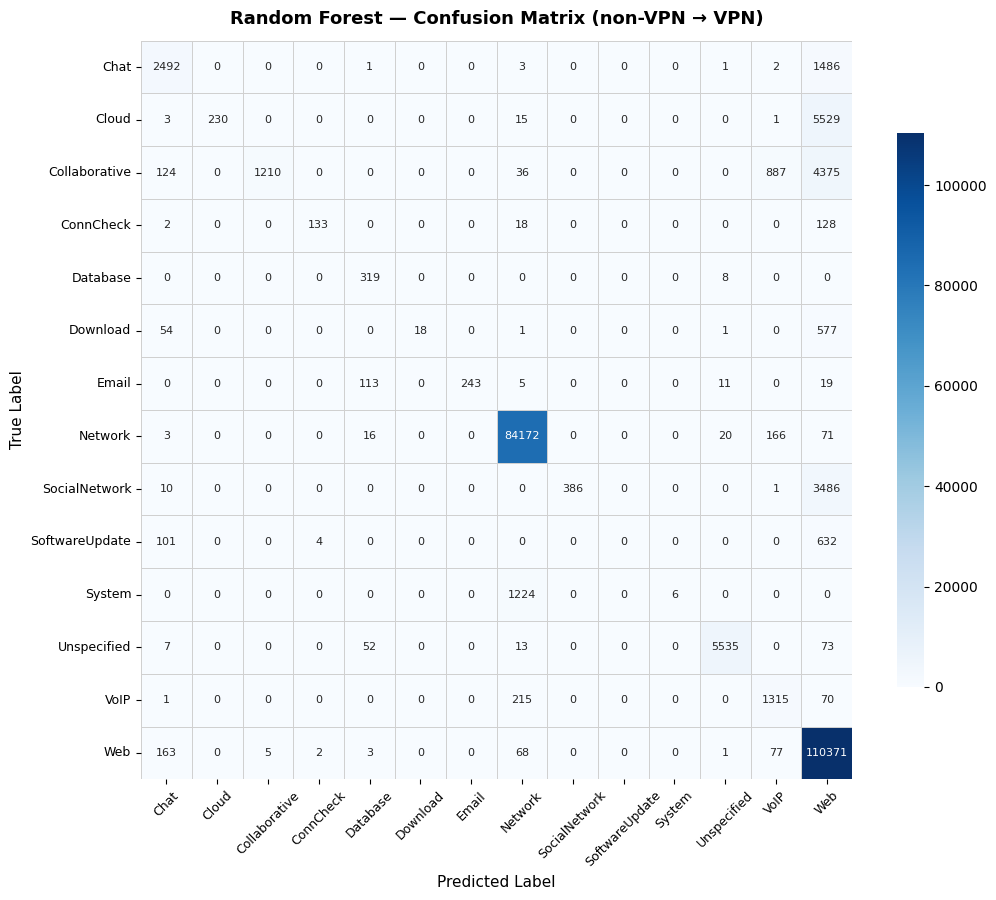


Bootstrap CI: RF  (B=1000, 95% CI)
VPN test set: 226,314 flows
  accuracy                 : 0.9121  95% CI [0.9110 – 0.9133]
  bal_accuracy             : 0.4886  95% CI [0.4825 – 0.4943]
  macro_f1                 : 0.5047  95% CI [0.4982 – 0.5108]
  weighted_f1              : 0.8830  95% CI [0.8815 – 0.8847]


,mean,CI_lower,CI_upper,std
metric,,,,
accuracy,0.912100,0.911000,0.913300,0.000600
bal_accuracy,0.488600,0.482500,0.494300,0.003100
macro_f1,0.504700,0.498200,0.510800,0.003200
weighted_f1,0.883000,0.881500,0.884700,0.000800


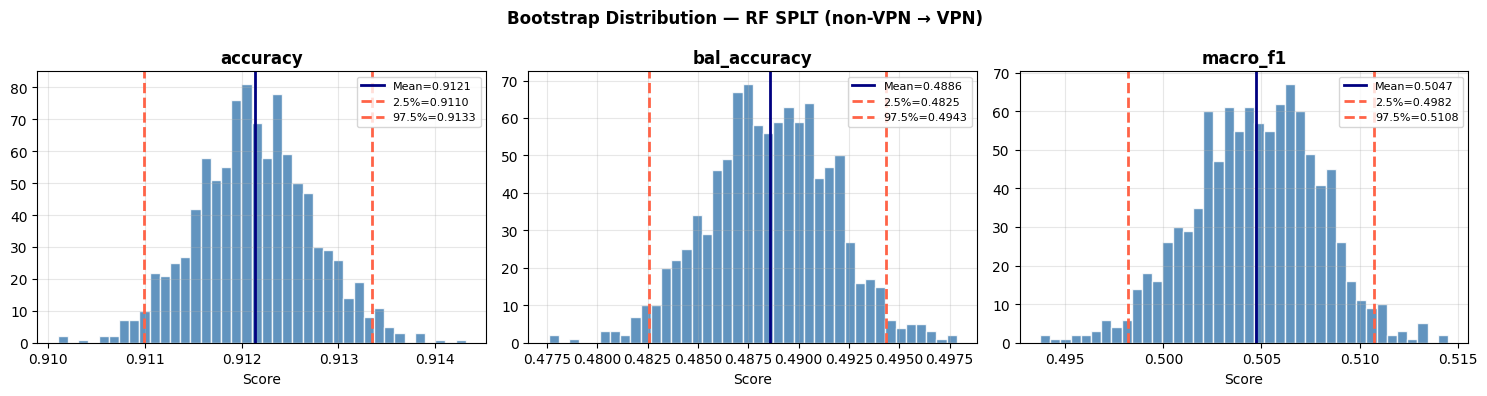

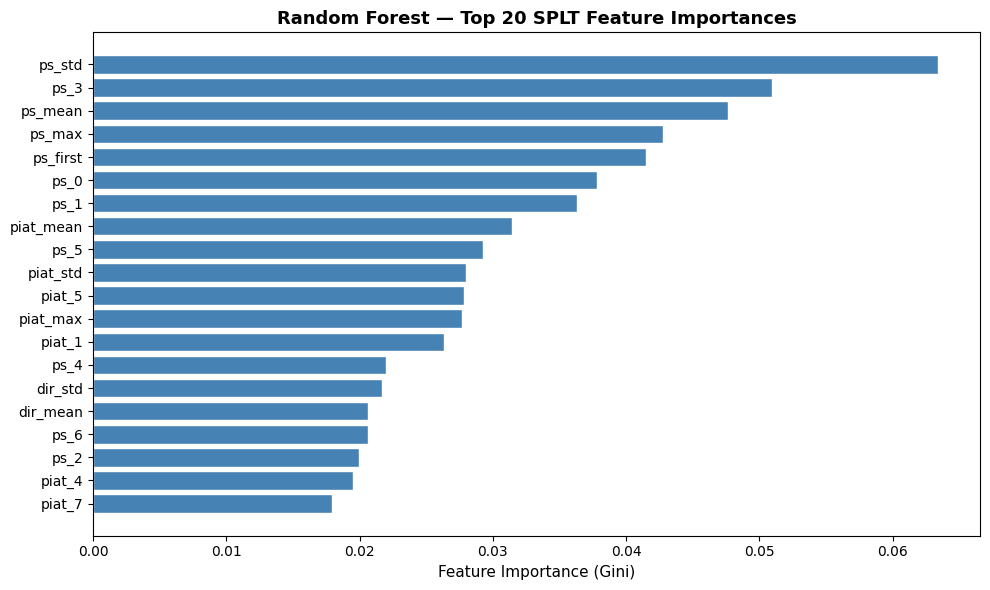

RF complete.


In [7]:
# ── Random Forest ──────────────────────────────────────────────────────────────
print('=== RANDOM FOREST ===')
print('Training on ALL non-VPN data...')

final_rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, n_jobs=-1,
    class_weight='balanced', random_state=SEED)
final_rf.fit(X_nonvpn, y_nonvpn)
print('RF trained.')

y_pred_rf  = final_rf.predict(X_vpn)
rf_metrics = compute_metrics(y_vpn, y_pred_rf)
show_metrics_table(rf_metrics, title='RF Final (all non-VPN → VPN)')

# Blue confusion matrix
cm_rf = confusion_matrix(y_vpn, y_pred_rf)
plot_blue_cm(cm_rf, list(le.classes_),
             title='Random Forest — Confusion Matrix (non-VPN → VPN)',
             save_path=os.path.join(OUT_RF, 'rf_confusion_matrix.png'))

# Bootstrap CI
rf_ci_df, rf_boot = run_bootstrap_ci(
    y_vpn, y_pred_rf, B=1000, seed=SEED, tag='RF', save_dir=OUT_RF)
display(rf_ci_df.style.background_gradient(cmap='Blues', axis=None))
plot_bootstrap_dist(rf_boot, ['accuracy', 'bal_accuracy', 'macro_f1'],
                    'Bootstrap Distribution — RF SPLT (non-VPN → VPN)',
                    save_path=os.path.join(OUT_RF, 'rf_bootstrap_dist.png'))

# Save report + metrics
with open(os.path.join(OUT_RF, 'rf_report.txt'), 'w') as f:
    f.write(classification_report(y_vpn, y_pred_rf, target_names=list(le.classes_), zero_division=0))
with open(os.path.join(OUT_RF, 'rf_final_metrics.json'), 'w') as f:
    json.dump(rf_metrics, f, indent=2)

# Feature importance — top 20
fi     = final_rf.feature_importances_
fi_idx = np.argsort(fi)[::-1][:20]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([FEAT_NAMES[i] for i in fi_idx[::-1]], fi[fi_idx[::-1]], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Random Forest — Top 20 SPLT Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_RF, 'rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('RF complete.')

## XGBoost

=== XGBOOST ===
Training on ALL non-VPN data...
XGBoost trained.


,accuracy,bal_accuracy,macro_f1,weighted_f1
XGBoost Final (all non-VPN → VPN),0.947300,0.674800,0.725700,0.941100


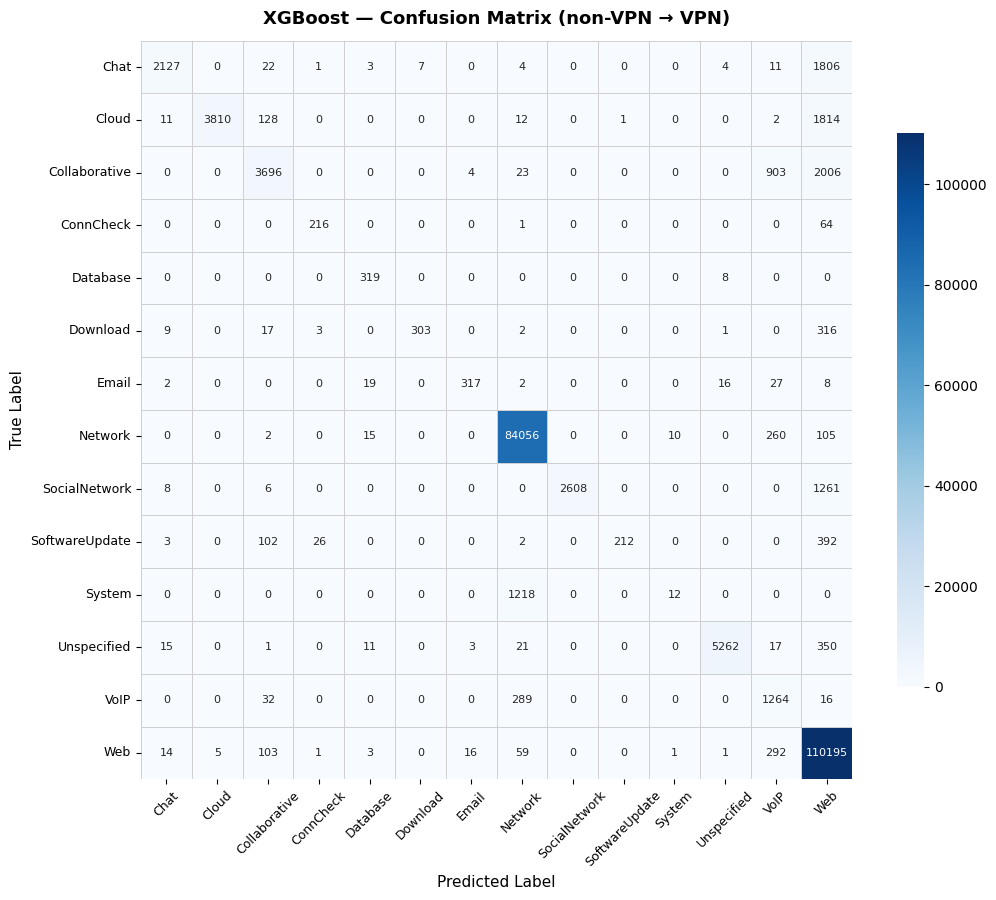


Bootstrap CI: XGB  (B=1000, 95% CI)
VPN test set: 226,314 flows
  accuracy                 : 0.9473  95% CI [0.9464 – 0.9483]
  bal_accuracy             : 0.6748  95% CI [0.6682 – 0.6811]
  macro_f1                 : 0.7257  95% CI [0.7193 – 0.7316]
  weighted_f1              : 0.9411  95% CI [0.9400 – 0.9422]


,mean,CI_lower,CI_upper,std
metric,,,,
accuracy,0.947300,0.946400,0.948300,0.000500
bal_accuracy,0.674800,0.668200,0.681100,0.003200
macro_f1,0.725700,0.719300,0.731600,0.003000
weighted_f1,0.941100,0.940000,0.942200,0.000600


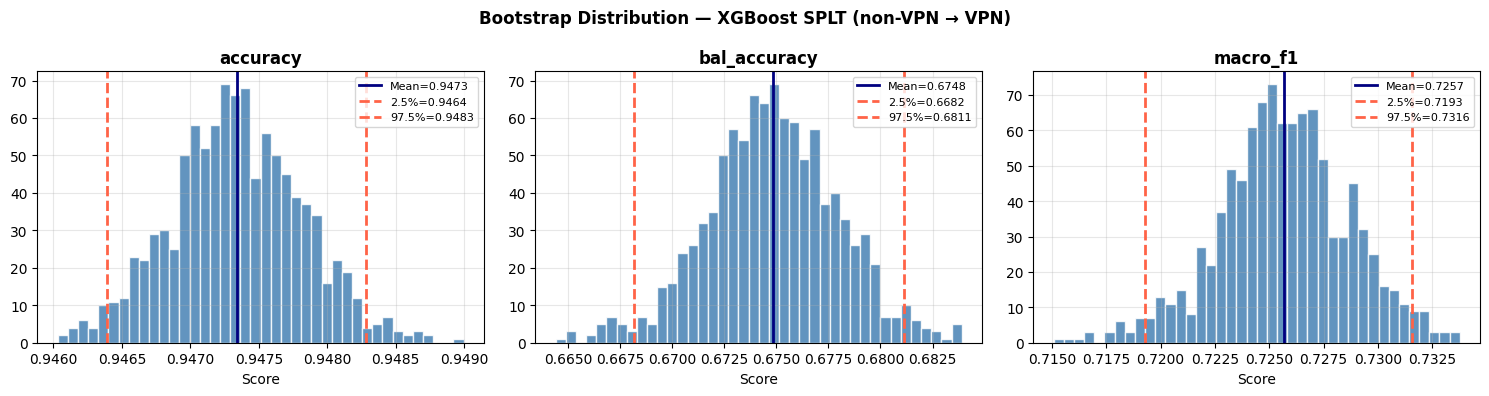

XGBoost complete.


In [8]:
# ── XGBoost ────────────────────────────────────────────────────────────────────
if not XGB_AVAILABLE:
    print('XGBoost not available — skipping.')
    xgb_metrics = {}; xgb_ci_df = None; xgb_boot = []
else:
    print('=== XGBOOST ===')
    print('Training on ALL non-VPN data...')

    final_xgb = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        n_jobs=-1, random_state=SEED, verbosity=0)
    final_xgb.fit(X_nonvpn, y_nonvpn)
    print('XGBoost trained.')

    y_pred_xgb  = final_xgb.predict(X_vpn)
    xgb_metrics = compute_metrics(y_vpn, y_pred_xgb)
    show_metrics_table(xgb_metrics, title='XGBoost Final (all non-VPN → VPN)')

    # Blue confusion matrix
    cm_xgb = confusion_matrix(y_vpn, y_pred_xgb)
    plot_blue_cm(cm_xgb, list(le.classes_),
                 title='XGBoost — Confusion Matrix (non-VPN → VPN)',
                 save_path=os.path.join(OUT_XGB, 'xgb_confusion_matrix.png'))

    # Bootstrap CI
    xgb_ci_df, xgb_boot = run_bootstrap_ci(
        y_vpn, y_pred_xgb, B=1000, seed=SEED, tag='XGB', save_dir=OUT_XGB)
    display(xgb_ci_df.style.background_gradient(cmap='Blues', axis=None))
    plot_bootstrap_dist(xgb_boot, ['accuracy', 'bal_accuracy', 'macro_f1'],
                        'Bootstrap Distribution — XGBoost SPLT (non-VPN → VPN)',
                        save_path=os.path.join(OUT_XGB, 'xgb_bootstrap_dist.png'))

    # Save
    with open(os.path.join(OUT_XGB, 'xgb_report.txt'), 'w') as f:
        f.write(classification_report(y_vpn, y_pred_xgb, target_names=list(le.classes_), zero_division=0))
    with open(os.path.join(OUT_XGB, 'xgb_final_metrics.json'), 'w') as f:
        json.dump(xgb_metrics, f, indent=2)
    print('XGBoost complete.')

## SHAP Analysis

Computing SHAP values on XGBoost (using VPN test set sample) ...


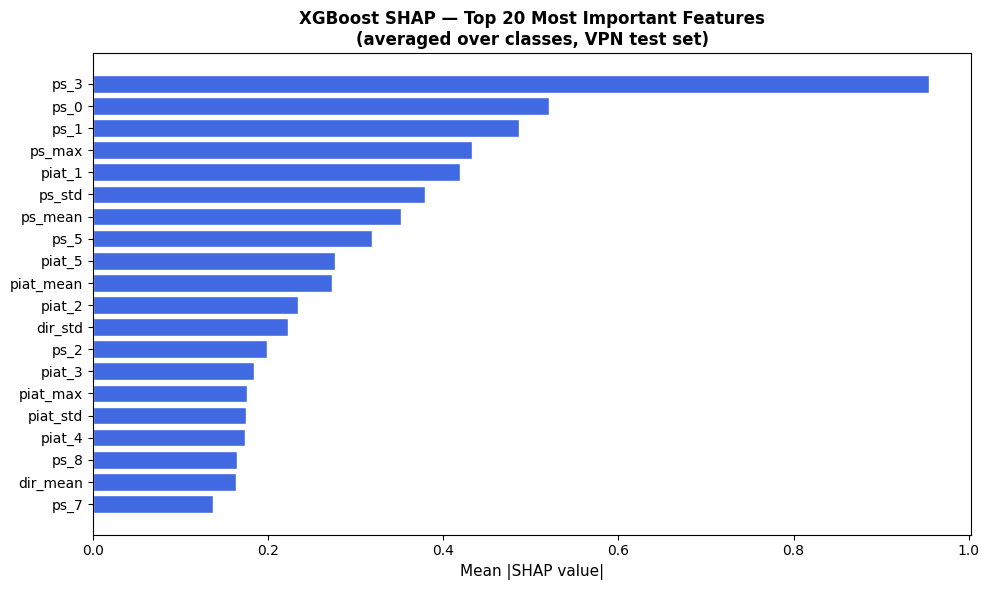

SHAP analysis complete.


In [12]:
# ── SHAP on XGBoost ────────────────────────────────────────────────────────────
if not XGB_AVAILABLE:
    print('XGBoost not available — skipping SHAP.')
elif not SHAP_AVAILABLE:
    print('SHAP not available — skipping SHAP analysis.')
else:
    print('Computing SHAP values on XGBoost (using VPN test set sample) ...')

    # Use a subsample for speed if VPN set is large
    MAX_SHAP_SAMPLES = 2000
    if len(X_vpn) > MAX_SHAP_SAMPLES:
        rng_idx = np.random.choice(len(X_vpn), MAX_SHAP_SAMPLES, replace=False)
        X_shap = X_vpn[rng_idx]
    else:
        X_shap = X_vpn

    explainer = shap.TreeExplainer(final_xgb)
    shap_values = explainer.shap_values(X_shap)  # (n_samples, n_features) or list for multi-class

    # For multi-class, shap_values is a list; take mean abs across classes
    _sv = np.array(shap_values)
    _nf = X_shap.shape[1]
    if _sv.ndim == 3:
        _fa = next((a for a in range(3) if _sv.shape[a] == _nf), None)
        if _fa is not None:
            _oa = tuple(a for a in range(3) if a != _fa)
            mean_abs_shap = np.abs(_sv).mean(axis=_oa)
        else:
            mean_abs_shap = np.abs(_sv).mean(axis=(0, 1))
    elif isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        mean_abs_shap = np.abs(_sv).mean(axis=0)
    mean_abs_shap = np.array(mean_abs_shap).flatten()

    shap_top_idx = np.argsort(mean_abs_shap)[::-1][:20]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([FEAT_NAMES[int(i)] for i in shap_top_idx[::-1]],
            mean_abs_shap[shap_top_idx[::-1]],
            color='royalblue', edgecolor='white')
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title('XGBoost SHAP — Top 20 Most Important Features\n(averaged over classes, VPN test set)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_XGB, 'xgb_shap_top20.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Save SHAP importances
    shap_df = pd.DataFrame({'feature': FEAT_NAMES, 'mean_abs_shap': mean_abs_shap})
    shap_df.sort_values('mean_abs_shap', ascending=False, inplace=True)
    shap_df.to_csv(os.path.join(OUT_XGB, 'xgb_shap_importances.csv'), index=False)
    print('SHAP analysis complete.')

## Save Models

In [13]:
import joblib
# ── Save trained models ─────────────────────────────────────────────────────
# RF
joblib.dump(final_rf, os.path.join(OUT_RF, 'rf_final_model.pkl'))
print(f'RF model saved  → {os.path.join(OUT_RF, "rf_final_model.pkl")}')

# XGBoost (native JSON format — framework-independent)
if XGB_AVAILABLE:
    final_xgb.save_model(os.path.join(OUT_XGB, 'xgb_final_model.json'))
    print(f'XGB model saved → {os.path.join(OUT_XGB, "xgb_final_model.json")}')


# Label encoder (needed to decode predictions)
joblib.dump(le, os.path.join(OUT_RF, 'label_encoder.pkl'))
print(f'LabelEncoder saved → {os.path.join(OUT_RF, "label_encoder.pkl")}')
print('All SPLT cross-domain models saved.')


RF model saved  → .\results_02_CrossDomain_RF_XGB_SPLT\RF\rf_final_model.pkl
XGB model saved → .\results_02_CrossDomain_RF_XGB_SPLT\XGB\xgb_final_model.json
LabelEncoder saved → .\results_02_CrossDomain_RF_XGB_SPLT\RF\label_encoder.pkl
All SPLT cross-domain models saved.


## Save Predictions

In [14]:
# ── Save predictions + probabilities for ROC / PR curve analysis ───────────────
# Format: y_true (int), y_pred (int), y_true_name, y_pred_name, prob_<ClassName> x n_classes
# Load with pd.read_csv for ROC curve drawing or calibration analysis.

def save_pred_csv(y_true, y_pred, proba, le, prefix, out_dir):
    """Save ground-truth labels, predicted labels, and class probabilities to CSV."""
    df = pd.DataFrame({
        'y_true':      y_true,
        'y_pred':      y_pred,
        'y_true_name': le.inverse_transform(y_true),
        'y_pred_name': le.inverse_transform(y_pred),
    })
    for j, cls in enumerate(le.classes_):
        df[f'prob_{cls}'] = proba[:, j]
    path = os.path.join(out_dir, f'{prefix}_predictions.csv')
    df.to_csv(path, index=False)
    print(f'  Saved: {prefix}_predictions.csv  ({len(df):,} rows, {len(le.classes_)} class proba cols)')
    return df

print('Saving predictions + probabilities ...')

# RF
proba_rf = final_rf.predict_proba(X_vpn)
save_pred_csv(y_vpn, y_pred_rf, proba_rf, le, 'rf', OUT_RF)

# XGBoost
if XGB_AVAILABLE:
    proba_xgb = final_xgb.predict_proba(X_vpn)
    save_pred_csv(y_vpn, y_pred_xgb, proba_xgb, le, 'xgb', OUT_XGB)


# Class index → name mapping (shared across all models)
with open(os.path.join(OUT_BASE, 'class_names.json'), 'w') as f:
    json.dump({str(i): cls for i, cls in enumerate(le.classes_)}, f, indent=2)
print('Class name mapping saved → class_names.json')


Saving predictions + probabilities ...
  Saved: rf_predictions.csv  (226,314 rows, 14 class proba cols)
  Saved: xgb_predictions.csv  (226,314 rows, 14 class proba cols)
Class name mapping saved → class_names.json


## Model Comparison

=== COMPARISON SUMMARY (Bootstrap 95% CI on VPN test set) ===

Model Comparison (SPLT Features, non-VPN train → VPN test):


,Final Acc,Final Bal Acc,Final Macro F1,Final Weighted F1,Boot Macro F1,Boot F1 CI Lo,Boot F1 CI Hi
Model,,,,,,,
Random Forest,0.912100,0.488500,0.504700,0.883000,0.504700,0.498200,0.510800
XGBoost,0.947300,0.674800,0.725700,0.941100,0.725700,0.719300,0.731600



Saved: C:\Users\Yasameen\enhanced_v2\results_02_CrossDomain_RF_XGB_SPLT/SPLT_model_comparison.csv


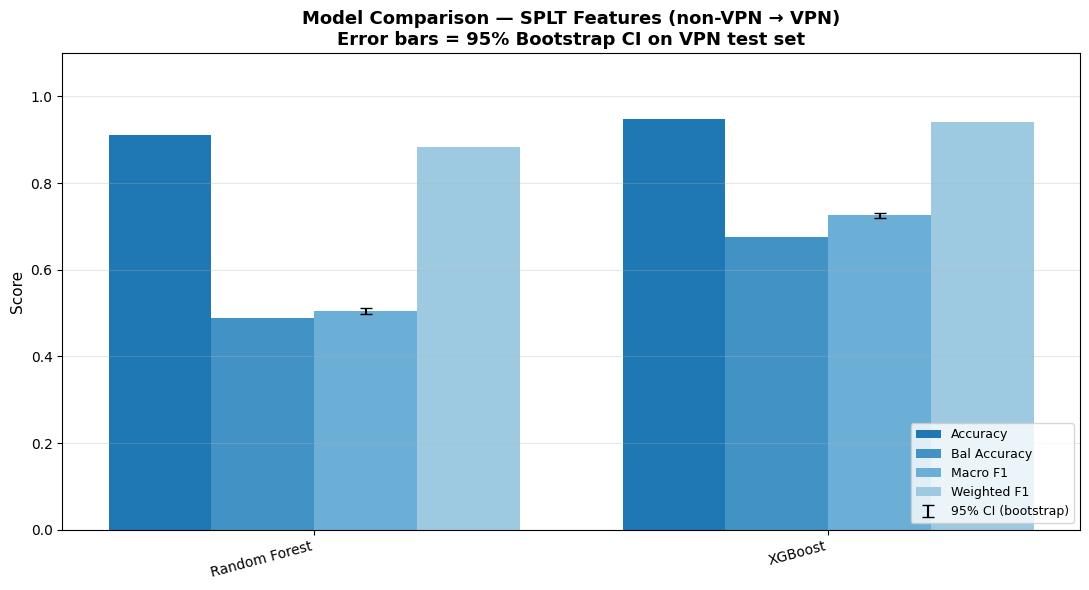


Publishable summary (Macro F1, 95% CI):
  Random Forest       : F1 = 0.5047  95%CI [0.4982, 0.5108]
  XGBoost             : F1 = 0.7257  95%CI [0.7193, 0.7316]


In [15]:
# ── Comparison Summary Table ───────────────────────────────────────────────────
print('=== COMPARISON SUMMARY (Bootstrap 95% CI on VPN test set) ===')

def _ci(ci_df, metric):
    """Extract mean, CI lower, CI upper from bootstrap CI DataFrame."""
    try:
        return (ci_df.loc[metric, 'mean'],
                ci_df.loc[metric, 'CI_lower'],
                ci_df.loc[metric, 'CI_upper'])
    except Exception:
        return float('nan'), float('nan'), float('nan')

rows = []

# RF
rf_f1_mean, rf_f1_lo, rf_f1_hi = _ci(rf_ci_df, 'macro_f1')
rows.append({
    'Model':             'Random Forest',
    'Final Acc':         rf_metrics['accuracy'],
    'Final Bal Acc':     rf_metrics['bal_accuracy'],
    'Final Macro F1':    rf_metrics['macro_f1'],
    'Final Weighted F1': rf_metrics['weighted_f1'],
    'Boot Macro F1':     rf_f1_mean,
    'Boot F1 CI Lo':     rf_f1_lo,
    'Boot F1 CI Hi':     rf_f1_hi,
})

# XGBoost
if XGB_AVAILABLE and xgb_ci_df is not None:
    xgb_f1_mean, xgb_f1_lo, xgb_f1_hi = _ci(xgb_ci_df, 'macro_f1')
    rows.append({
        'Model':             'XGBoost',
        'Final Acc':         xgb_metrics['accuracy'],
        'Final Bal Acc':     xgb_metrics['bal_accuracy'],
        'Final Macro F1':    xgb_metrics['macro_f1'],
        'Final Weighted F1': xgb_metrics['weighted_f1'],
        'Boot Macro F1':     xgb_f1_mean,
        'Boot F1 CI Lo':     xgb_f1_lo,
        'Boot F1 CI Hi':     xgb_f1_hi,
    })
else:
    rows.append({'Model': 'XGBoost', 'Final Acc': float('nan'),
                 'Final Bal Acc': float('nan'), 'Final Macro F1': float('nan'),
                 'Final Weighted F1': float('nan'), 'Boot Macro F1': float('nan'),
                 'Boot F1 CI Lo': float('nan'), 'Boot F1 CI Hi': float('nan')})


num_cols = ['Final Acc', 'Final Bal Acc', 'Final Macro F1', 'Final Weighted F1',
            'Boot Macro F1', 'Boot F1 CI Lo', 'Boot F1 CI Hi']
df_comp = pd.DataFrame(rows).set_index('Model')
df_comp[num_cols] = df_comp[num_cols].astype(float).round(4)

print('\nModel Comparison (SPLT Features, non-VPN train → VPN test):')
display(df_comp[num_cols].style.background_gradient(
    cmap='Blues', axis=0,
    subset=['Final Acc', 'Final Bal Acc', 'Final Macro F1', 'Final Weighted F1']))

# Save comparison
df_comp.to_csv(os.path.join(OUT_BASE, 'SPLT_model_comparison.csv'))
print(f'\nSaved: {os.path.abspath(OUT_BASE)}/SPLT_model_comparison.csv')

# Bar chart with bootstrap error bars
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(df_comp))
w = 0.2
ax.bar(x - w*1.5, df_comp['Final Acc'],        w, label='Accuracy',     color='#1f77b4')
ax.bar(x - w*0.5, df_comp['Final Bal Acc'],     w, label='Bal Accuracy', color='#4292c6')
ax.bar(x + w*0.5, df_comp['Final Macro F1'],    w, label='Macro F1',     color='#6baed6')
ax.bar(x + w*1.5, df_comp['Final Weighted F1'], w, label='Weighted F1',  color='#9ecae1')

# Bootstrap CI error bars on Macro F1 bars
f1_vals = df_comp['Final Macro F1'].values
ci_lo   = df_comp['Boot F1 CI Lo'].values
ci_hi   = df_comp['Boot F1 CI Hi'].values
ax.errorbar(x + w*0.5, f1_vals,
            yerr=[f1_vals - ci_lo, ci_hi - f1_vals],
            fmt='none', color='black', capsize=4, linewidth=1.5,
            label='95% CI (bootstrap)')

ax.set_title('Model Comparison — SPLT Features (non-VPN → VPN)\n'
             'Error bars = 95% Bootstrap CI on VPN test set',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(df_comp.index, rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_BASE, 'SPLT_model_comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nPublishable summary (Macro F1, 95% CI):')
for model, row in df_comp.iterrows():
    print(f'  {model:20s}: F1 = {row["Final Macro F1"]:.4f}  95%CI [{row["Boot F1 CI Lo"]:.4f}, {row["Boot F1 CI Hi"]:.4f}]')
